# Data Preprocessing - Sheffield Road Collision Dataset

This notebook covers the complete preprocessing pipeline for the "Filtered_Sheffield_Traffic_Data.csv". The pipeline is structured as follows:
1.

---
# 1. Configuration and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')

ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    pipeline_cfg = yaml.safe_load(f)['preprocessing']

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide': nb_cfg['plotting']['figsize_wide'],
    'figsize_square': nb_cfg['plotting']['figsize_square'],
    'palette': nb_cfg['plotting']['palette'],
}

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Pipeline config loaded from: config.yml')
print('Notebook config loaded from: notebook-config.yml')


Project root: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework
Pipeline config loaded from: config.yml
Notebook config loaded from: notebook-config.yml


---
# 2. Load and Initial Exploration

In [2]:
df_raw = pd.read_csv(ROOT_DIR / pipeline_cfg['raw_data_path'], encoding='utf-8-sig')

print(f'Shape: {df_raw.shape}')
print('Column dtypes:{df_raw.dtypes}')
print('First 3 rows:')
df_raw.head(3)

df_raw.describe()

Shape: (7933, 44)
Column dtypes:{df_raw.dtypes}
First 3 rows:


,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,...,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
count,7933.000000,7868.000000,7868.000000,3693.000000,3693.000000,7933.0,7933.000000,7933.000000,7933.000000,7933.000000,...,7933.000000,7933.000000,7933.000000,7933.000000,7933.000000,7933.000000,7933.000000,7933.000000,2696.000000,2696.000000
mean,1997.699987,435874.978012,388616.385231,-1.460544,53.385982,14.0,2.813185,1.696080,1.300139,4.195260,...,0.097819,0.062145,0.758855,0.279970,-0.307702,0.795286,-0.623598,-0.592714,0.235354,0.727925
std,11.405115,3611.910193,21711.218888,0.057606,0.036132,0.0,0.420590,0.680231,0.740409,1.925508,...,0.623956,0.433466,3.439919,1.069283,1.074735,1.456096,1.378463,0.628883,0.336737,0.362611
min,1979.000000,340780.000000,338800.000000,-2.891207,52.945371,14.0,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000
25%,1988.000000,434169.000000,385300.000000,-1.485380,53.364713,14.0,3.000000,1.000000,1.000000,3.000000,...,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.019863,0.729183
50%,1997.000000,435590.000000,387358.000000,-1.464603,53.382543,14.0,3.000000,2.000000,1.000000,4.000000,...,0.000000,0.000000,0.000000,1.000000,-1.000000,2.000000,-1.000000,-1.000000,0.091170,0.892594
75%,2007.000000,437725.500000,390050.000000,-1.430020,53.407034,14.0,3.000000,2.000000,1.000000,6.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,-1.000000,0.000000,0.242816,0.972434
max,2020.000000,487490.000000,984700.000000,-1.328944,54.247744,14.0,3.000000,10.000000,11.000000,7.000000,...,7.000000,7.000000,21.000000,3.000000,2.000000,2.000000,7.000000,1.000000,1.000000,1.000000


In [3]:
# True NaN missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_simmary = pd.DataFrame({'missing_count': missing, "missing_%": missing_pct})
print('Columns with NaN missing values:')
missing_simmary[missing_simmary['missing_count'] > 0]

Columns with NaN missing values:


,missing_count,missing_%
location_easting_osgr,65,0.82
location_northing_osgr,65,0.82
longitude,4240,53.45
latitude,4240,53.45
local_authority_highway_current,5314,66.99
collision_adjusted_severity_serious,5237,66.02
collision_adjusted_severity_slight,5237,66.02


In [4]:
# STATS19 sentinel -1 values (encoded as "unknown/not applicable" in the raw data)
numeric_cols = df_raw.select_dtypes(include="number").columns
sentinel_counts = {
    col: (df_raw[col] == pipeline_cfg['sentinel_value']).sum()
    for col in numeric_cols
}
sentinel_df = pd.DataFrame.from_dict(sentinel_counts, orient="index", columns=["sentinel_-1_count"])
print('Columns containing sentinel -1 values:')
sentinel_df[sentinel_df['sentinel_-1_count'] > 0].sort_values('sentinel_-1_count', ascending=False)

Columns containing sentinel -1 values:


,sentinel_-1_count
enhanced_severity_collision,7322
did_police_officer_attend_scene_of_accident,5517
collision_injury_based,5313
trunk_road_flag,3129
urban_or_rural_area,3127
second_road_number,2538
junction_control,2367
second_road_class,6
carriageway_hazards_historic,4
road_surface_conditions,3


In [5]:
# Duplicate rows and duplicate collision_index entries
print(f'Fully duplicate rows: {df_raw.duplicated().sum()}')
print(f'Duplicate collision_index values: {df_raw["collision_index"].duplicated().sum()}')
print(f'\nYear range: {df_raw["collision_year"].min()} - {df_raw["collision_year"].max()}')

Fully duplicate rows: 0
Duplicate collision_index values: 609

Year range: 1979 - 2020


---
# 3. Visualize Raw Data

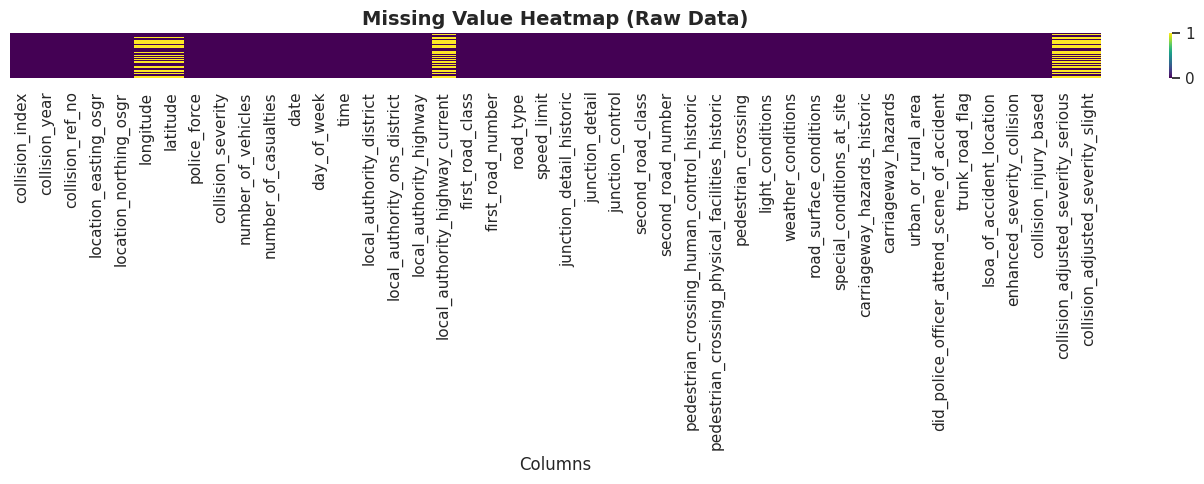

In [6]:
fig, ax = plt.subplots(figsize=NB_CONFIG['figsize_wide'])
sns.heatmap(
    df_raw.isnull(),
    yticklabels=False,
    cbar=True,
    cmap='viridis',
    ax=ax
)
ax.set_title("Missing Value Heatmap (Raw Data)", fontsize=14, fontweight="bold")
ax.set_xlabel("Columns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

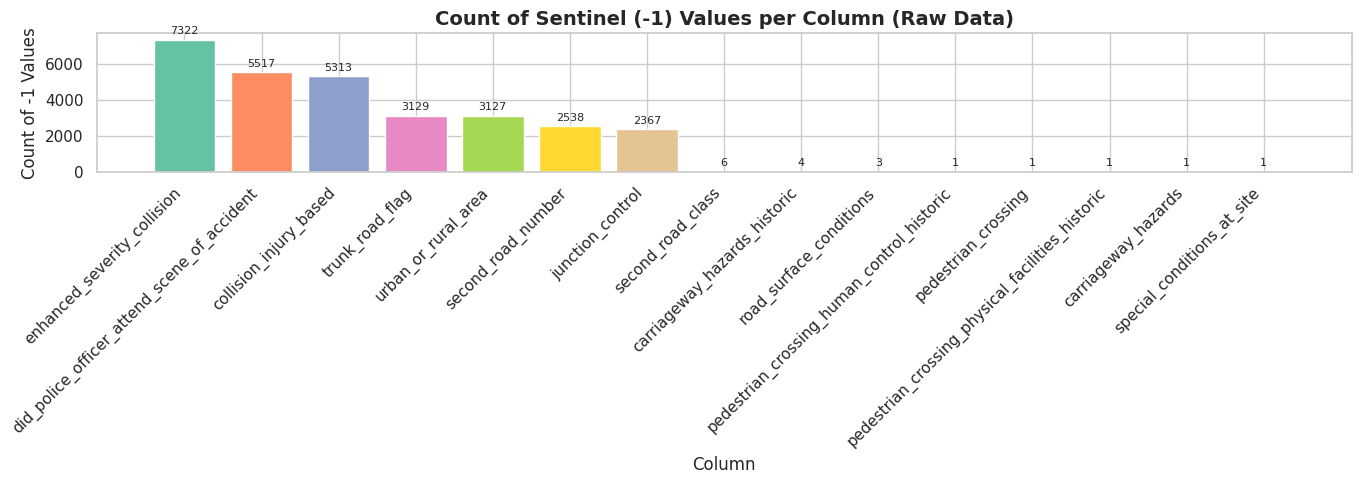

In [7]:
# Sentinel -1 distribution across key columns
sentinel_plot_data = sentinel_df[sentinel_df['sentinel_-1_count'] > 0].sort_values('sentinel_-1_count', ascending=False)

fig, ax = plt.subplots(figsize=NB_CONFIG['figsize_wide'])
bars = ax.bar(sentinel_plot_data.index, sentinel_plot_data['sentinel_-1_count'], color=sns.color_palette(NB_CONFIG['palette']))
ax.set_title('Count of Sentinel (-1) Values per Column (Raw Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Count of -1 Values')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    ax.annotate(
        f'{int(bar.get_height())}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center', fontsize=8
    )
plt.tight_layout()
plt.show()

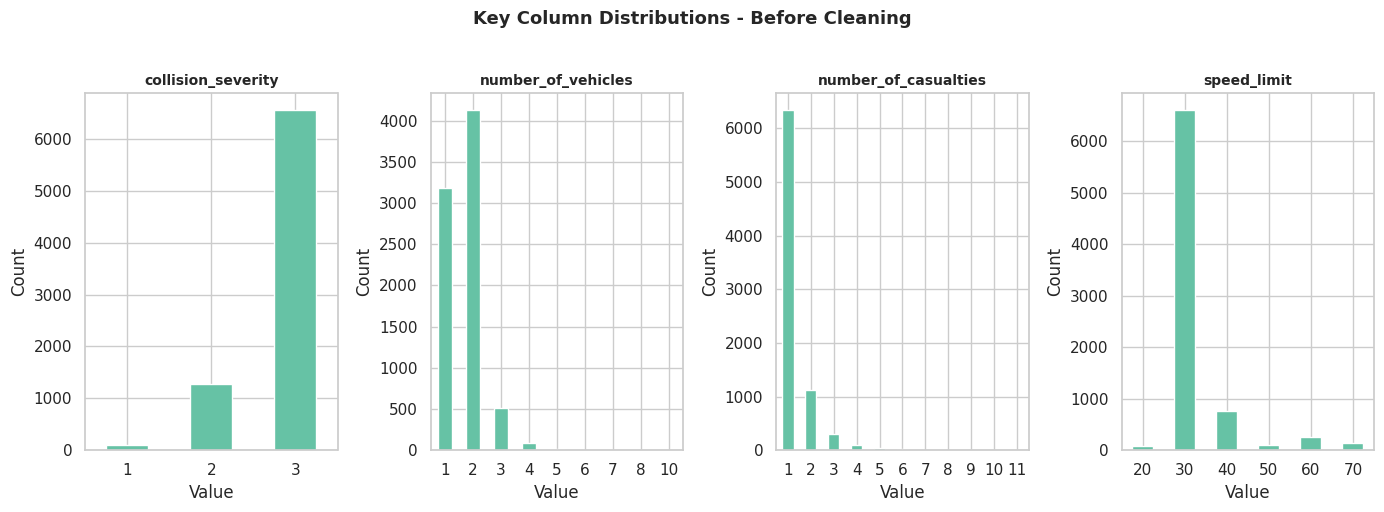

In [8]:
# Distribution of key target related columns
cols_to_plot = ['collision_severity', 'number_of_vehicles', 'number_of_casualties', 'speed_limit']
fig, axes = plt.subplots(1, len(cols_to_plot), figsize=NB_CONFIG['figsize_wide'])

for ax, col in zip(axes, cols_to_plot):
    df_raw[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=sns.color_palette(NB_CONFIG['palette'])[0])
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

fig.suptitle('Key Column Distributions - Before Cleaning', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

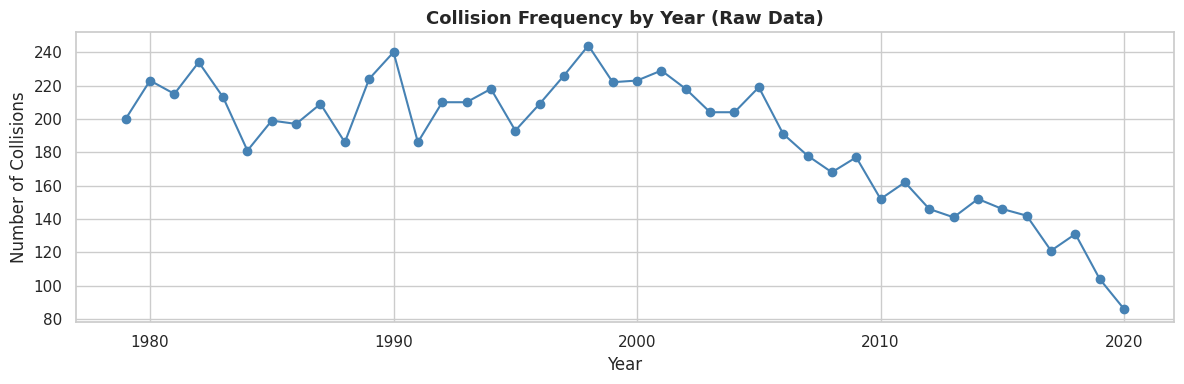

In [9]:
# Collision count over years
fig, ax = plt.subplots(figsize=(12, 4))
df_raw['collision_year'].value_counts().sort_index().plot(kind='line', ax=ax, marker='o', color='steelblue')
ax.set_title('Collision Frequency by Year (Raw Data)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Collisions')
plt.tight_layout()
plt.show()

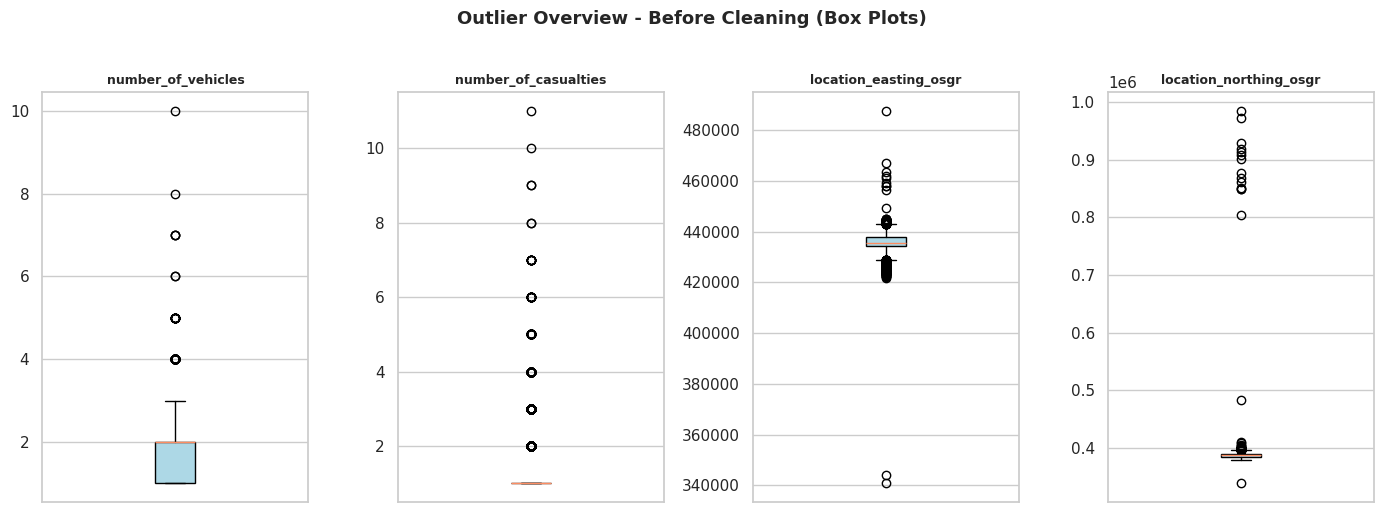

In [10]:
# Box plot of continuous cols to spot outliers visually
fig, axes = plt.subplots(1, len(pipeline_cfg['outlier_cols']), figsize=NB_CONFIG['figsize_wide'])

for ax, col in zip(axes, pipeline_cfg['outlier_cols']):
    ax.boxplot(df_raw[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xticks([])

fig.suptitle('Outlier Overview - Before Cleaning (Box Plots)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 4. Drop Irrelvant/Redundant Columns

- Justification for each drop is defined in config.yml

In [11]:
df = df_raw.copy()

# Drop only columns that actually exist in the dataframe (defensive)
cols_to_drop = [c for c in pipeline_cfg['drop_cols'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f'Columns dropped: {cols_to_drop}')
print(f'Shape after drop: {df.shape}')

Columns dropped: ['collision_ref_no', 'police_force', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic', 'enhanced_severity_collision', 'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight', 'lsoa_of_accident_location']
Shape after drop: (7933, 31)


---
# 5. Handle Sentinel Values

- In the STATS19 dataset, `-1` encodes "unknown" or "not applicable" so must be  treated as missing data.

In [12]:
# Replace -1 with NaN in categorical colums, then mode-impute
for col in pipeline_cfg['sentinel_categorical_cols']:
    if col not in df.columns:
        continue
    n_sentinel = (df[col] == pipeline_cfg['sentinel_value']).sum()
    if n_sentinel > 0:
        df[col] = df[col].replace(pipeline_cfg['sentinel_value'], np.nan)
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'{col}: replaced {n_sentinel} sentinel values → mode imputed with {mode_val}')

# For sentinel_keep_as_category, recode -1 as a valid category integer
for col in pipeline_cfg['sentinel_keep_as_category']:
    if col not in df.columns:
        continue
    n_sentinel = (df[col] == pipeline_cfg['sentinel_value']).sum()
    print(f'{col}: keeping {n_sentinel} sentinel -1 values as "unknown" category')

junction_control: replaced 2367 sentinel values → mode imputed with 4.0
second_road_class: replaced 6 sentinel values → mode imputed with 6.0
pedestrian_crossing: replaced 1 sentinel values → mode imputed with 0.0
road_surface_conditions: replaced 3 sentinel values → mode imputed with 1.0
special_conditions_at_site: replaced 1 sentinel values → mode imputed with 0.0
carriageway_hazards: replaced 1 sentinel values → mode imputed with 0.0
urban_or_rural_area: replaced 3127 sentinel values → mode imputed with 1.0
trunk_road_flag: replaced 3129 sentinel values → mode imputed with 2.0
did_police_officer_attend_scene_of_accident: keeping 5517 sentinel -1 values as "unknown" category
second_road_number: keeping 2538 sentinel -1 values as "unknown" category


---
# 6. Handle True Missing Values (NaN)

- After sentinel treatment, remaining NaNs are in spatial coordinate columns. KNN imputation is used to estimate these from neighbouring records, which is more principled than mean/median for geospatial data.

In [13]:
# KNN Imputation for spatial coordinates
knn_cols = [c for c in pipeline_cfg['knn_impute_cols'] if c in df.columns]

print('Missing before KNN imputation:')
for col in knn_cols:
    print(f'  {col}: {df[col].isnull().sum()}')

knn_imputer = KNNImputer(n_neighbors=pipeline_cfg['knn_neighbors'])
df[knn_cols] = knn_imputer.fit_transform(df[knn_cols])

print('\nMissing after KNN imputation:')
for col in knn_cols:
    print(f'  {col}: {df[col].isnull().sum()}')

Missing before KNN imputation:
  location_easting_osgr: 65
  location_northing_osgr: 65

Missing after KNN imputation:
  location_easting_osgr: 0
  location_northing_osgr: 0


In [14]:
# Drop longitude/latitude (replaced by easting/northing after imputation)
# longitude/latitude have 4240 NaNs and are redundant once we have easting/northing
for col in ['longitude', 'latitude']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print('Remaining missing values after all imputation:')
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None - dataset is complete.')

Remaining missing values after all imputation:
local_authority_highway_current    5314
dtype: int64


---
# 7. Fix Data Types

In [15]:
df['date'] = pd.to_datetime(df['date'], dayfirst = True, errors="coerce")

df['hour_of_day'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour
df.drop(columns=['time'], inplace=True)

df['month'] = df['date'].dt.month
df.drop(columns=['date'], inplace=True)  # raw date not needed after feature extraction

int_cols = [
    'collision_severity', 'day_of_week', 'road_type', 'speed_limit',
    'junction_detail', 'junction_control', 'second_road_class',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area',
    'first_road_class', 'collision_injury_based',
]
for col in int_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

print('Updated dtypes:')
print(df.dtypes)



Updated dtypes:
collision_index                                    str
collision_year                                   int64
location_easting_osgr                          float64
location_northing_osgr                         float64
collision_severity                               int64
number_of_vehicles                               int64
number_of_casualties                             int64
day_of_week                                      int64
local_authority_highway_current                    str
first_road_class                                 int64
first_road_number                                int64
road_type                                        int64
speed_limit                                      int64
junction_detail                                  int64
junction_control                                 int64
second_road_class                                int64
second_road_number                               int64
pedestrian_crossing                            fl

---
# 8. Duplicate Detection and Precision

- The raw data has 609 duplicate `collision_index` values. These are not fully duplicate rows — they represent re-coded records across dataset editions (STATS19 data can have the same incident indexed differently in different years of release). We retain the most recently updated record.

In [16]:
n_before = len(df)

df.sort_values('collision_year', ascending=False, inplace=True)
df.drop_duplicates(subset='collision_index', keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows before deduplication: {n_before}')
print(f'Rows after deduplication:  {len(df)}')
print(f'Rows removed: {n_before - len(df)}')

Rows before deduplication: 7933
Rows after deduplication:  7324
Rows removed: 609


---
# 9. Outlier Detection and Treatment

- IQR based detection is used. Outliers are Winsorized rather than dropped, preserving record count and avoiding loss of (rare but) genuine events.

In [17]:
def winsorize_iqr(series, multiplier=1.5):
    """Cap values outside IQR whiskers. Returns capped series and bounds."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 - multiplier * iqr
    return series.clip(lower=lower, upper=upper), lower, upper

outlier_cols = [c for c in pipeline_cfg['outlier_cols'] if c in df.columns]

# Capture pre-winsorisation state for comparison plot
df_pre_winsor = df[outlier_cols].copy()

for col in outlier_cols:
    n_outliers_before = (
        (df[col] < df[col].quantile(0.25) - pipeline_cfg['iqr_multiplier'] * (df[col].quantile(0.75) - df[col].quantile(0.25))) |
        (df[col] > df[col].quantile(0.75) + pipeline_cfg['iqr_multiplier'] * (df[col].quantile(0.75) - df[col].quantile(0.25)))
    ).sum()
    df[col], lower, upper = winsorize_iqr(df[col], pipeline_cfg['iqr_multiplier'])
    print(f'{col}: {n_outliers_before} outlier(s) Winsorized => bounds [{lower:.2f}, {upper:.2f}]')

number_of_vehicles: 97 outlier(s) Winsorized => bounds [-0.50, 0.50]
number_of_casualties: 1477 outlier(s) Winsorized => bounds [1.00, 1.00]
location_easting_osgr: 368 outlier(s) Winsorized => bounds [428990.00, 432450.00]
location_northing_osgr: 156 outlier(s) Winsorized => bounds [378290.00, 382990.00]


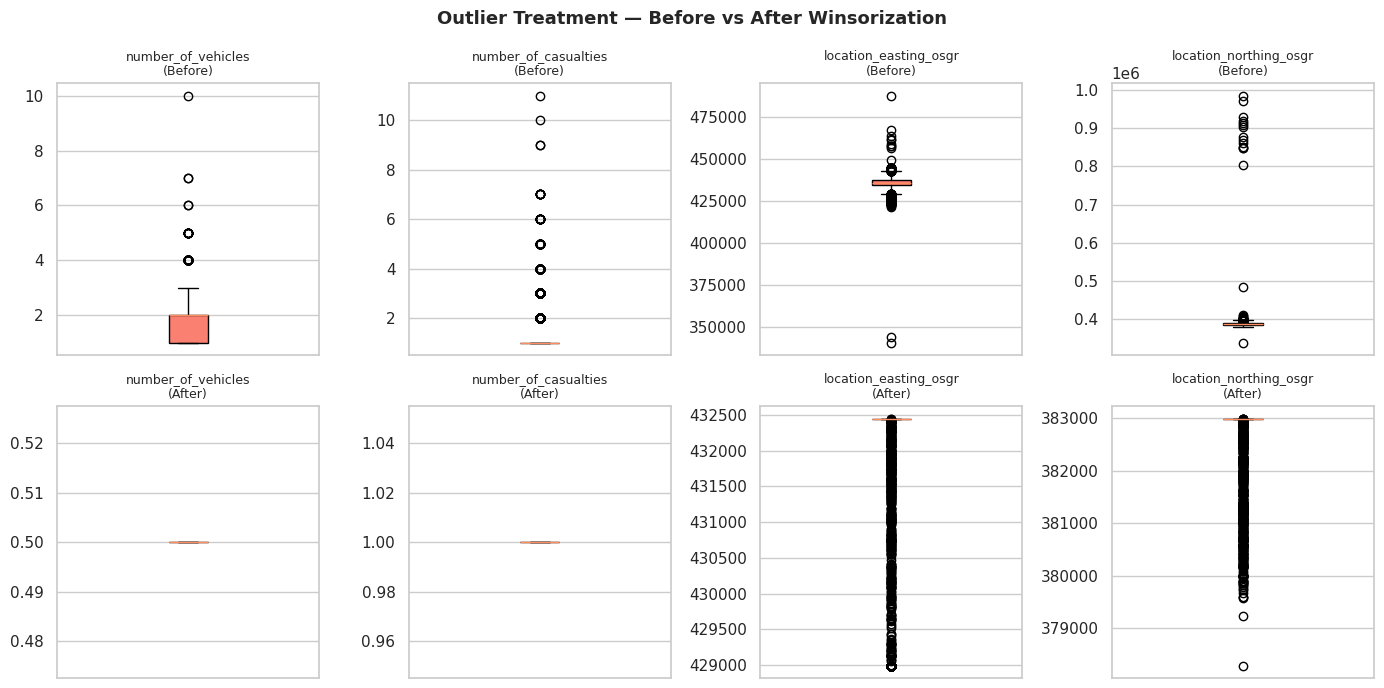

In [18]:
# Before vs After Winsorization box plots
fig, axes = plt.subplots(2, len(outlier_cols), figsize=(14, 7))

for i, col in enumerate(outlier_cols):
    axes[0, i].boxplot(df_pre_winsor[col], patch_artist=True, boxprops=dict(facecolor='salmon'))
    axes[0, i].set_title(f'{col}\n(Before)', fontsize=9)
    axes[0, i].set_xticks([])

    axes[1, i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    axes[1, i].set_title(f'{col}\n(After)', fontsize=9)
    axes[1, i].set_xticks([])

fig.suptitle('Outlier Treatment — Before vs After Winsorization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 10. Feature Engineering

- New features derived from existing columns to improve ML signal

In [19]:
df['is_weekend'] = df['day_of_week'].isin([1, 7]).astype(int)

def hour_to_period(hour):
    if 6 <= hour < 12:
        return 0   # morning
    elif 12 <= hour < 17:
        return 1   # afternoon
    elif 17 <= hour < 21:
        return 2   # evening
    else:
        return 3   # night

df['time_period'] = df['hour_of_day'].apply(hour_to_period)

df['multi_vehicle'] = (df['number_of_vehicles'] > 1).astype(int)

print('New features added: is_weekend, time_period, multi_vehicle')
df[['is_weekend', 'time_period', 'multi_vehicle', 'hour_of_day']].head()

New features added: is_weekend, time_period, multi_vehicle


,is_weekend,time_period,multi_vehicle,hour_of_day
0,0,0,0,8
1,1,3,0,21
2,1,1,0,12
3,0,3,0,5
4,0,2,0,18


---
# 11. Scaling and Normalization

- Min-Max scaling is applied to continous numerical columns, bringing all values into [0, 1].

In [20]:
scale_cols = [c for c in pipeline_cfg['scale_cols'] if c in df.columns]

# Capture pre-scale distributions
df_pre_scale = df[scale_cols].copy()

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('Scaled columns (now in [0, 1]):')
df[scale_cols].describe().loc[['min', 'max']]

Scaled columns (now in [0, 1]):


,location_easting_osgr,location_northing_osgr
min,0.0,0.0
max,1.0,1.0


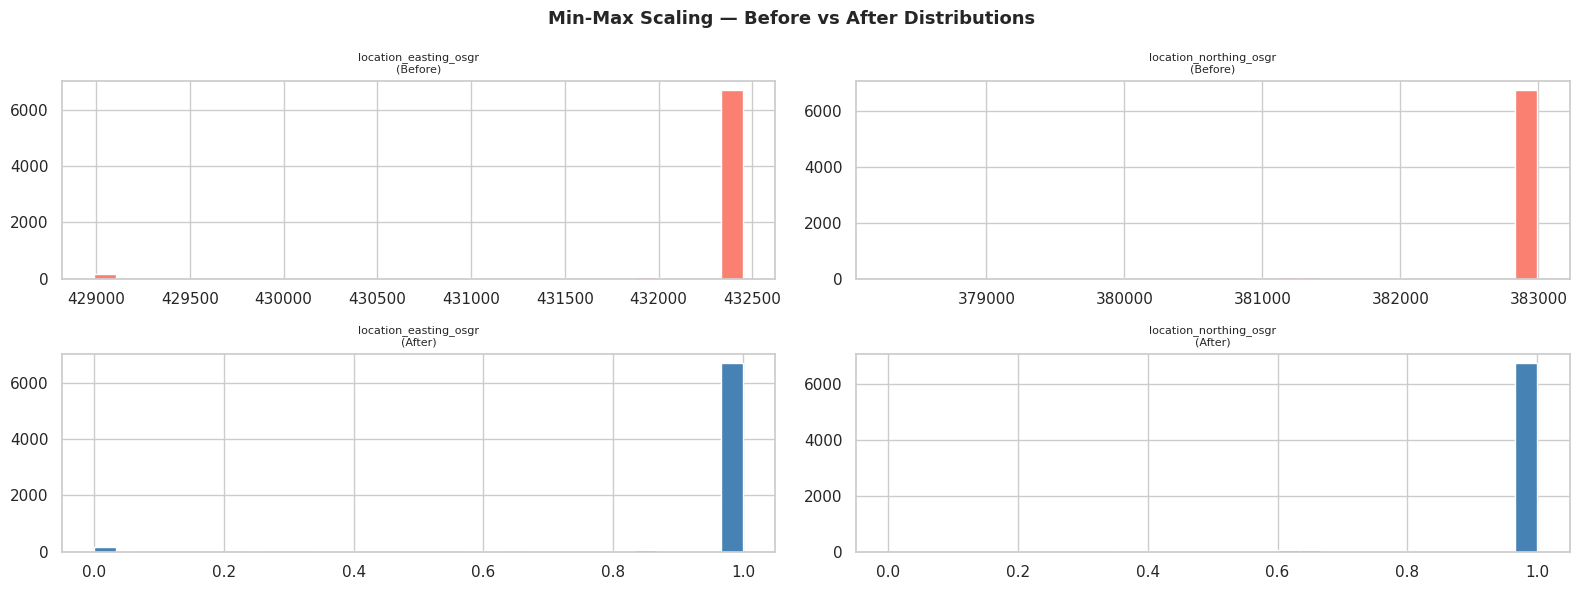

In [21]:
# Before vs After scaling distributions
fig, axes = plt.subplots(2, len(scale_cols), figsize=(16, 6))

for i, col in enumerate(scale_cols):
    axes[0, i].hist(df_pre_scale[col], bins=30, color='salmon', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Before)', fontsize=8)

    axes[1, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[1, i].set_title(f'{col}\n(After)', fontsize=8)

fig.suptitle('Min-Max Scaling — Before vs After Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 12. Post Cleaning Validation and Summary Visualizations

In [22]:
# Final missing value check
final_missing = df.isnull().sum().sum()
print(f'Total missing values in cleaned dataset: {final_missing}')
print(f'Final shape: {df.shape}')
print(f'Columns retained: {list(df.columns)}')

Total missing values in cleaned dataset: 5314
Final shape: (7324, 32)
Columns retained: ['collision_index', 'collision_year', 'location_easting_osgr', 'location_northing_osgr', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'collision_injury_based', 'hour_of_day', 'month', 'is_weekend', 'time_period', 'multi_vehicle']


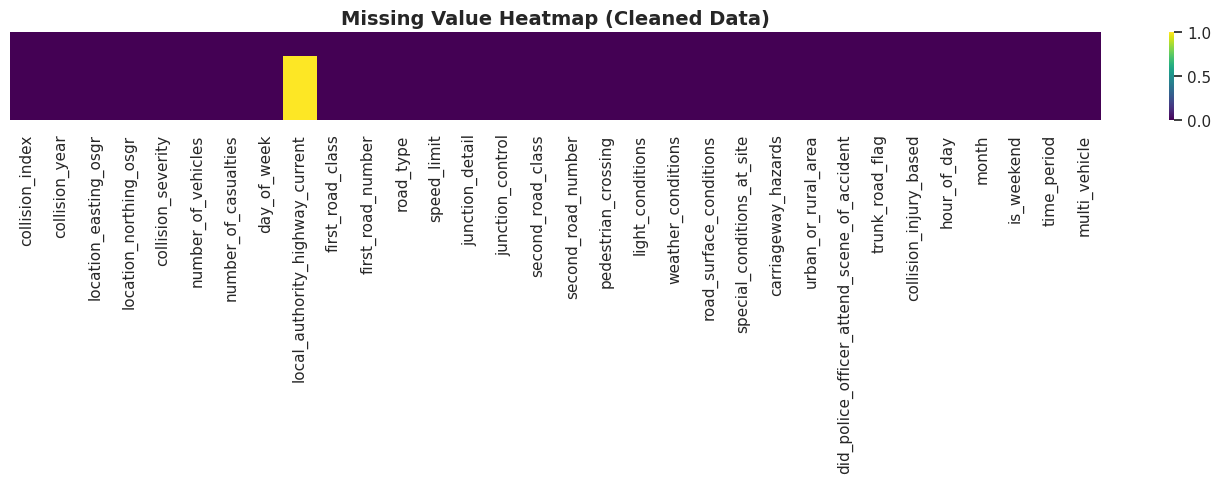

In [23]:
# Cleaned missing value heatmap
fig, ax = plt.subplots(figsize=NB_CONFIG['figsize_wide'])
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap (Cleaned Data)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

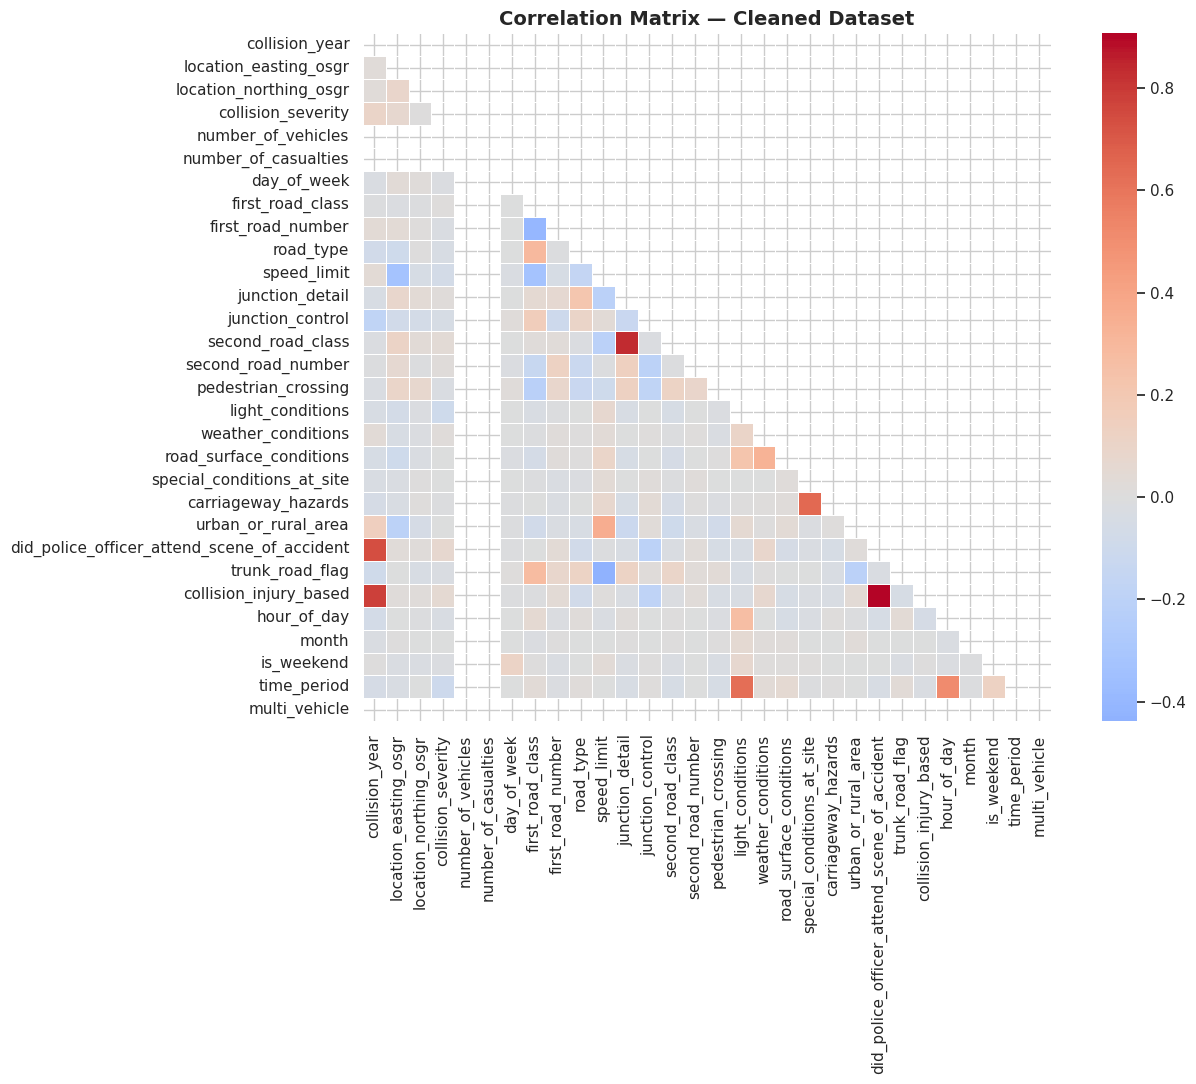

In [24]:
# Correlation matrix of cleaned numeric features
numeric_clean = df.select_dtypes(include='number').drop(columns=['collision_index'], errors='ignore')

fig, ax = plt.subplots(figsize=(14, 11))
corr = numeric_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Cleaned Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

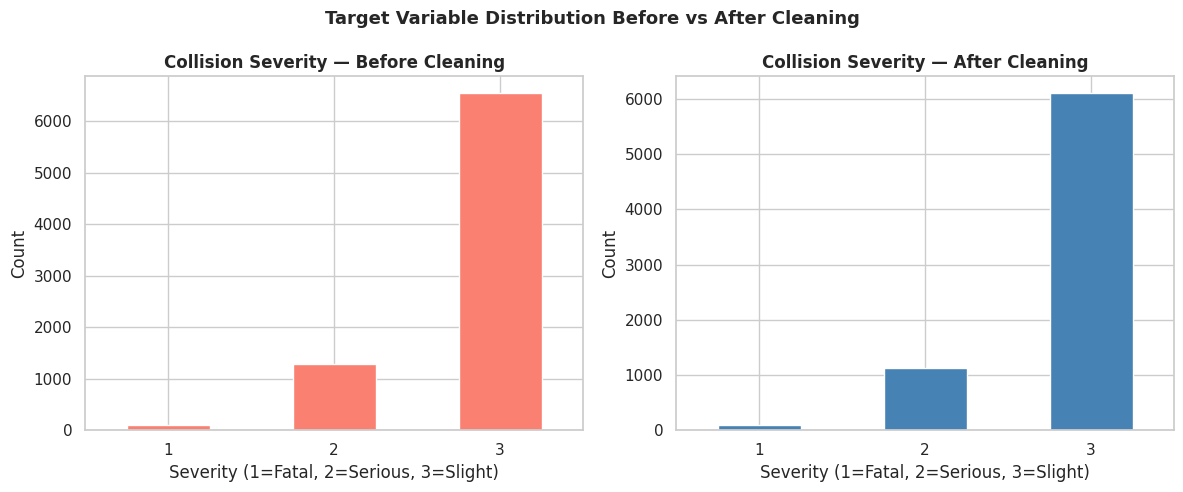

In [25]:
# Collision severity class distribution (target variable check)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

severity_before = df_raw['collision_severity'].value_counts().sort_index()
severity_after  = df['collision_severity'].value_counts().sort_index()

severity_before.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('Collision Severity — Before Cleaning', fontweight='bold')
axes[0].set_xlabel('Severity (1=Fatal, 2=Serious, 3=Slight)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

severity_after.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Collision Severity — After Cleaning', fontweight='bold')
axes[1].set_xlabel('Severity (1=Fatal, 2=Serious, 3=Slight)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Target Variable Distribution Before vs After Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Summary table: raw vs cleaned
summary = pd.DataFrame({
    'Metric': [
        'Total rows',
        'Total columns',
        'NaN missing values',
        'Sentinel -1 values (key cols)',
        'Duplicate collision_index',
    ],
    'Raw': [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        sum((df_raw[c] == -1).sum() for c in pipeline_cfg['sentinel_categorical_cols'] if c in df_raw.columns),
        df_raw['collision_index'].duplicated().sum(),
    ],
    'Cleaned': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        0,
        df['collision_index'].duplicated().sum(),
    ]
})
summary

,Metric,Raw,Cleaned
0,Total rows,7933,7324
1,Total columns,44,32
2,NaN missing values,24398,5314
3,Sentinel -1 values (key cols),8635,0
4,Duplicate collision_index,609,0


In [27]:
df.to_csv(ROOT_DIR / pipeline_cfg['output_path'], index=False)
print(f'Cleaned dataset saved to: {ROOT_DIR / pipeline_cfg["output_path"]}')

Cleaned dataset saved to: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/storage/processed/Sheffield_Traffic_Data_Processed.csv
